In [1]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [2]:
# --- Step 2: Load Data ---
df = pd.read_csv('creditcard.csv')
print("creditcard.csv loaded.")

creditcard.csv loaded.


In [3]:
# --- Step 3: Feature Engineering (DO THIS BEFORE SPLIT) ---
scaler = StandardScaler()
df['Scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Scaled_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df['Hour'] = df['Time'].apply(lambda x: (x // 3600) % 24)
df = df.drop(['Time', 'Amount'], axis=1)
print("Feature Engineering complete. 'Scaled_Amount', 'Scaled_Time', and 'Hour' created.")


Feature Engineering complete. 'Scaled_Amount', 'Scaled_Time', and 'Hour' created.


In [4]:
# --- Step 4: Define X and y (AFTER processing) ---
X = df.drop('Class', axis=1)
y = df['Class']
print("X and y defined.")

X and y defined.


In [5]:
# --- Step 5: Split Data (AFTER processing) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Data split into train and test sets. X_test now has all correct features.")


Data split into train and test sets. X_test now has all correct features.


In [6]:
# --- Step 6: Apply SMOTE (to training data only) ---
print("Applying SMOTE to training data...")
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("SMOTE complete.")

Applying SMOTE to training data...
SMOTE complete.


In [7]:
# --- Step 7: Train the "Credit Card Expert" Model ---
print("Training 'Credit Card Expert' (Random Forest) model...")
# --- THIS IS THE CRITICAL FIX ---
# We MUST use n_jobs=1 to prevent the server from deadlocking.
rf_model_creditcard = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1) 
# --- END OF FIX ---
rf_model_creditcard.fit(X_train_res, y_train_res)
print("Model A (Credit Card) training complete!")
print("-" * 50)

Training 'Credit Card Expert' (Random Forest) model...
Model A (Credit Card) training complete!
--------------------------------------------------


In [8]:
# --- Step 8: Evaluate the Model ---
y_pred_rf = rf_model_creditcard.predict(X_test)
print("Model A Evaluation:")
print(classification_report(y_test, y_pred_rf))
print("-" * 50)

Model A Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.88      0.78      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.89      0.91     85443
weighted avg       1.00      1.00      1.00     85443

--------------------------------------------------


In [9]:
# --- Step 9: Save the "Expert" Model ---
joblib.dump(rf_model_creditcard, 'model_creditcard.joblib')
print("SUCCESS: 'model_creditcard.joblib' has been saved!")
print("This notebook is complete.")

SUCCESS: 'model_creditcard.joblib' has been saved!
This notebook is complete.


In [10]:
from sklearn.model_selection import train_test_split

# Assuming X_res and y_res are your oversampled data
# For evaluation, we will use the original, imbalanced data to get a realistic performance metric
# Let's split the original data first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Now, we apply SMOTE only to the training data
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original training data shape: {X_train.shape}")
print(f"Resampled training data shape: {X_train_res.shape}")
print(f"Test data shape: {X_test.shape}")
print("-" * 50)
print("Resampled training class distribution:", y_train_res.value_counts())
print("Test class distribution:", y_test.value_counts())

Original training data shape: (199364, 31)
Resampled training data shape: (398040, 31)
Test data shape: (85443, 31)
--------------------------------------------------
Resampled training class distribution: Class
0    199020
1    199020
Name: count, dtype: int64
Test class distribution: Class
0    85295
1      148
Name: count, dtype: int64


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train the Logistic Regression model on the resampled training data
lr_model = LogisticRegression(solver='liblinear', random_state=42)
lr_model.fit(X_train_res, y_train_res)

# Make predictions on the original, imbalanced test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
print("Logistic Regression Results:")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
Confusion Matrix:
[[83300  1995]
 [   19   129]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.87      0.11       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.55     85443
weighted avg       1.00      0.98      0.99     85443



In [12]:
from sklearn.ensemble import RandomForestClassifier

# Train the Random Forest model on the resampled training data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

# Make predictions on the original, imbalanced test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Results:")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
Confusion Matrix:
[[85280    15]
 [   33   115]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.88      0.78      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.89      0.91     85443
weighted avg       1.00      1.00      1.00     85443



In [13]:
import xgboost as xgb

# Train the XGBoost model on the resampled training data
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train_res, y_train_res)

# Make predictions on the original, imbalanced test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Results:")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results:
Confusion Matrix:
[[85262    33]
 [   27   121]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.82      0.80       148

    accuracy                           1.00     85443
   macro avg       0.89      0.91      0.90     85443
weighted avg       1.00      1.00      1.00     85443



Epoch 1/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 49442388.0000 - val_loss: 1914.3849
Epoch 2/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2005.9878 - val_loss: 1958.8518
Epoch 3/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1966.6219 - val_loss: 1953.6860
Epoch 4/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2547.5034 - val_loss: 1648.5586
Epoch 5/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2207.2666 - val_loss: 364.7212
Epoch 6/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 758.8075 - val_loss: 48.2783
Epoch 7/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 655.4297 - val_loss: 253.8795
Epoch 8/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1225.7871 - val_loss: 25.7444
Epoch 9/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 644.0646 - val_loss: 4.8671
Epoch 10/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 803.8031 - val_loss: 479.3883
Epoch 11/100
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - l

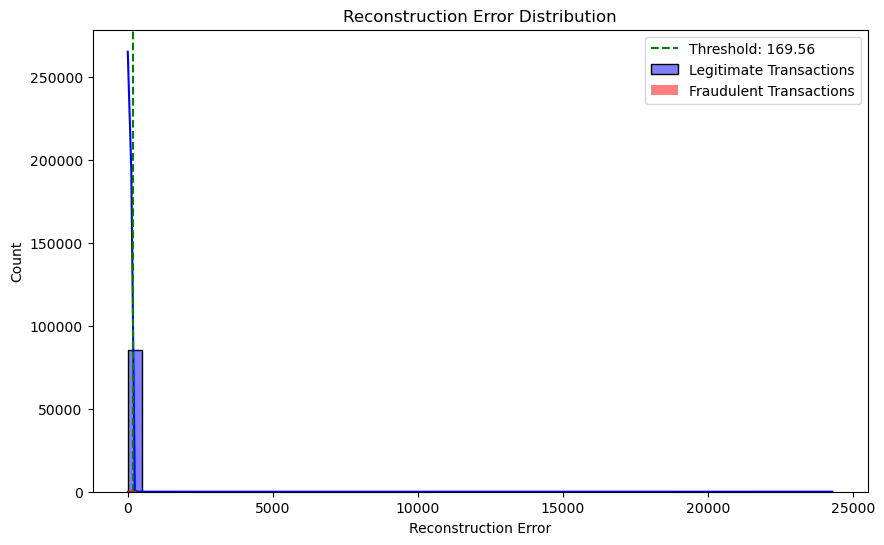

In [14]:
# Re-import all necessary libraries for a clean start
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter

# Load the dataset and split it
df = pd.read_csv('creditcard.csv')
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# The Autoencoder will be trained only on legitimate transactions
# This is crucial for its anomaly detection capabilities
X_train_legit = X_train[y_train == 0]

# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Build the Autoencoder model
# The encoder part learns a compressed representation
input_layer = Input(shape=(X_train_legit.shape[1],))
encoder = Dense(32, activation="relu")(input_layer)
encoder = Dense(16, activation="relu")(encoder)
latent_view = Dense(8, activation="relu")(encoder)

# The decoder part learns to reconstruct the original data
decoder = Dense(16, activation="relu")(latent_view)
decoder = Dense(32, activation="relu")(decoder)
output_layer = Dense(X_train_legit.shape[1], activation="linear")(decoder)

# Create the model
autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Train the Autoencoder
# We use EarlyStopping to prevent overfitting
history = autoencoder.fit(
    X_train_legit, X_train_legit,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5)],
    verbose=1
)

# Function to get the reconstruction error
def get_reconstruction_errors(model, data):
    predictions = model.predict(data)
    mse = np.mean(np.power(data - predictions, 2), axis=1)
    return mse

# Get reconstruction errors for both legitimate and fraudulent transactions
legit_errors = get_reconstruction_errors(autoencoder, X_test[y_test == 0])
fraud_errors = get_reconstruction_errors(autoencoder, X_test[y_test == 1])

# Determine an optimal threshold
# We'll use the 95th percentile of the legitimate errors as a simple threshold
threshold = np.percentile(legit_errors, 95)
print(f"\nReconstruction Error Threshold: {threshold}")

# Classify transactions based on the threshold
y_pred_ae = (get_reconstruction_errors(autoencoder, X_test) > threshold).astype(int)

# Evaluate the Autoencoder's performance
print("\nAutoencoder Results:")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_ae))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ae))

# Visualize the reconstruction error distribution
plt.figure(figsize=(10, 6))
sns.histplot(legit_errors, bins=50, kde=True, color='blue', label='Legitimate Transactions')
sns.histplot(fraud_errors, bins=50, kde=True, color='red', label='Fraudulent Transactions')
plt.axvline(threshold, color='green', linestyle='--', label=f'Threshold: {threshold:.2f}')
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.legend()
plt.show()



In [15]:
import joblib

# Save your NEWLY trained model. 
# This will replace the old 'fraud_detection_model.joblib' file.
joblib.dump(rf_model, 'fraud_detection_model.joblib') 

print("New, retrained model has been saved!")

New, retrained model has been saved!


In [16]:
# --- Evidence of Data Cleaning: Missing Values ---
print("Checking for missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values in dataset:", df.isnull().sum().sum())

Checking for missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values in dataset: 0


In [17]:
# --- Evidence of Data Cleaning: Duplicate Rows ---
print("Checking for duplicate rows:")
initial_rows = df.shape[0]
print(f"Number of rows before checking duplicates: {initial_rows}")
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {num_duplicates}")

# If duplicates were found, show the dropping step (optional if none found)
if num_duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Number of rows after dropping duplicates: {df.shape[0]}")
else:
    print("No duplicate rows to remove.")

Checking for duplicate rows:
Number of rows before checking duplicates: 284807
Number of duplicate rows found: 1081
Number of rows after dropping duplicates: 283726


In [18]:
# --- Evidence of Preprocessing: Scaling ---
print("\nDataset structure after scaling 'Amount' and 'Time':")
# Show the first few rows with the new Scaled_Amount and Scaled_Time columns
print(df.head())
# Show info to confirm original columns are gone and scaled ones are present
df.info()


Dataset structure after scaling 'Amount' and 'Time':
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0

In [19]:
import joblib

# 'rf_model' is the variable name of the Random Forest you trained in this notebook
# We are now saving it with its "expert" name for the new hybrid system.

joblib.dump(rf_model, 'model_creditcard.joblib')

print("SUCCESS: Your 'Credit Card Expert' model has been saved as 'model_creditcard.joblib'")

SUCCESS: Your 'Credit Card Expert' model has been saved as 'model_creditcard.joblib'
